<div style="
    background: linear-gradient(120deg, #0f2027, #203a43, #2c5364);
    color: #e0f2fe;
    font-weight: 900;
    padding: 26px;
    border-radius: 18px;
    text-align: center;
    font-size: 33px;
    box-shadow:
        0 8px 25px rgba(0,0,0,0.6),
        inset 0 0 15px rgba(34, 211, 238, 0.6);
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 1px;
">
    <span style="color:#22d3ee;">BRAIN TUMOUR</span><br>
    <span style="color:#f97316;">
        DETECTION
    </span>
</div>


<div style="
    background: linear-gradient(135deg, #1e293b, #0f172a);
    color: #fbbf24;
    font-weight: 800;
    padding: 22px;
    border-radius: 22px;
    text-align: left;
    font-size: 32px;
    box-shadow: 0 0 30px rgba(251, 191, 36, 0.7);
    font-family: Georgia, serif;
    border: 2px solid #38bdf8;
">
    IMPORT LIBRARIES,  LAYERS,  OPTIMIZERS
</div>


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical
import os
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

<div style="
    background: linear-gradient(135deg, #1e293b, #0f172a);
    color: #fbbf24;
    font-weight: 800;
    padding: 22px;
    border-radius: 22px;
    text-align: left;
    font-size: 32px;
    box-shadow: 0 0 30px rgba(251, 191, 36, 0.7);
    font-family: Georgia, serif;
    border: 2px solid #38bdf8;
">
    ENCODING
</div>


In [17]:
encoder=OneHotEncoder()
encoder.fit([[0],[1]])

OneHotEncoder()

# DATASET CREATION
# BRAIN TUMOUR IMAGE

In [18]:


data = []
paths = []
result = []

# Load Tumor Images (YES folder)
for r, d, f in os.walk(r"C:\Users\Shuhaib\OneDrive\Documents\archive (1)\yes"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            paths.append(os.path.join(r, file))

for path in paths:
    try:
        img = Image.open(path).convert("RGB")   # ensure 3 channels
        img = img.resize((128, 128))
        img = np.array(img) / 255.0             # normalize

        if img.shape == (128, 128, 3):
            data.append(img)
            result.append(1)   # 1 = Tumor

    except Exception as e:
        print("Error loading image:", path)

In [19]:
paths = []

for r, d, f in os.walk(r"C:\Users\Shuhaib\OneDrive\Documents\archive (1)\no"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            paths.append(os.path.join(r, file))

for path in paths:
    img = Image.open(path).convert("RGB")   # convert to 3 channel
    img = img.resize((128,128))
    img = np.array(img) / 255.0             # normalize

    if img.shape == (128,128,3):
        data.append(img)
        result.append(0)   # simpler than encoder

In [20]:

data=np.array(data)
data.shape

(253, 128, 128, 3)

# VISUALISATION 

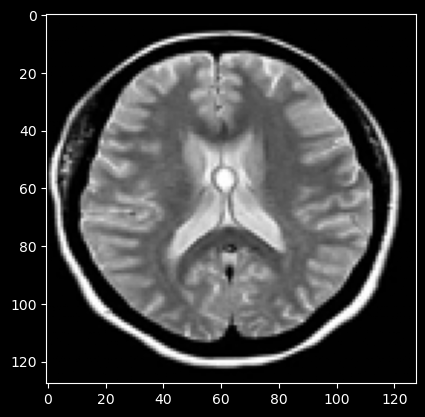

In [21]:
plt.imshow(data[19])

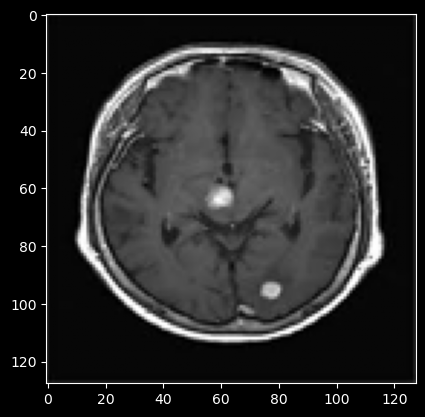

In [22]:
plt.imshow(data[207])

</div><div style="
    background: linear-gradient(135deg, #1e293b, #0f172a);
    color: #fbbf24;
    font-weight: 800;
    padding: 22px;
    border-radius: 22px;
    text-align: left;
    font-size: 32px;
    box-shadow: 0 0 30px rgba(251, 191, 36, 0.7);
    font-family: Georgia, serif;
    border: 2px solid #38bdf8;
">
    SPLITTING AND SHUFFLING DATA
</div>


# DATA SPLITTING

In [23]:
x_train,x_test,y_train,y_test=train_test_split(data,result,test_size=0.2,shuffle=True,random_state=0)

</div><div style="
    background: linear-gradient(135deg, #1e293b, #0f172a);
    color: #fbbf24;
    font-weight: 800;
    padding: 22px;
    border-radius: 22px;
    text-align: left;
    font-size: 32px;
    box-shadow: 0 0 30px rgba(251, 191, 36, 0.7);
    font-family: Georgia, serif;
    border: 2px solid #38bdf8;
">
    ADDING LAYERS
</div>


In [24]:


# -------------------------
# STEP 1: Load Images + Labels
# -------------------------

import cv2
data_path = r"C:\Users\Shuhaib\OneDrive\Documents\archive (1)"  # your main folder
categories = ["no", "yes"]   # folder names

result = []
labels = []

for category in categories:
    folder_path = os.path.join(data_path, category)
    label = categories.index(category)   # no=0 , yes=1
    
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (128,128))
        
        result.append(img)
        labels.append(label)

# Convert to numpy
x = np.array(result)
y = np.array(labels)

# Normalize
x = x / 255.0

# -------------------------
# STEP 2: Train Test Split
# -------------------------

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# -------------------------
# STEP 3: Build Model
# -------------------------

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))   # Binary output

# -------------------------
# STEP 4: Compile
# -------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# STEP 5: Train
# -------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test)
)

# -------------------------
# STEP 6: Evaluate
# -------------------------

loss, accuracy = model.evaluate(x_test, y_test)
print("Accuracy:", accuracy)

C:\Users\Shuhaib\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 544ms/step - accuracy: 0.6683 - loss: 0.7860 - val_accuracy: 0.8039 - val_loss: 0.4783
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 477ms/step - accuracy: 0.7574 - loss: 0.5142 - val_accuracy: 0.8824 - val_loss: 0.4517
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 444ms/step - accuracy: 0.8168 - loss: 0.4461 - val_accuracy: 0.9020 - val_loss: 0.3354
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 459ms/step - accuracy: 0.8119 - loss: 0.3981 - val_accuracy: 0.9216 - val_loss: 0.3281
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 438ms/step - accuracy: 0.9109 - loss: 0.2780 - val_accuracy: 0.9216 - val_loss: 0.2380
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 452ms/step - accuracy: 0.8960 - loss: 0.2515 - val_accuracy: 0.7647 - val_loss: 0.4220
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 479ms/step - accuracy: 0.8911 - loss: 0.2867 - val_accuracy: 0.8824 - val_loss: 0.3234
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 465ms/step - accuracy: 0.9257 - loss: 0.2026 - val_accuracy: 0.9412 - val_loss:

<div style="
    background: #09090b;      /* dark purple-gray background */
    color: #23e18e;           /* bright yellow text */
    font-weight: 900;
    padding: 25px; 
    border-radius: 16px; 
    text-align: center;
    font-size: 29px;
    box-shadow: 0 0 15px #23e18e;  /* golden glow */
    font-family: Georgia, serif;
">
    COMPILE
</div>

In [25]:
x_train.shape

(202, 128, 128, 3)

In [26]:
y_train.shape

(202,)

In [27]:
score=model.evaluate(x_test,y_test,batch_size=64)
print(f"\nTest accuracy: {100.0 * score[1]:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9216 - loss: 0.2500

Test accuracy: 92.2%


<div style="
    background: #09090b;      /* dark purple-gray background */
    color: #23e18e;           /* bright yellow text */
    font-weight: 900;
    padding: 25px; 
    border-radius: 16px; 
    text-align: center;
    font-size: 29px;
    box-shadow: 0 0 15px #23e18e;  /* golden glow */
    font-family: Georgia, serif;
">
    PREDICTION
</div>

(1, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
Prediction: No Tumor


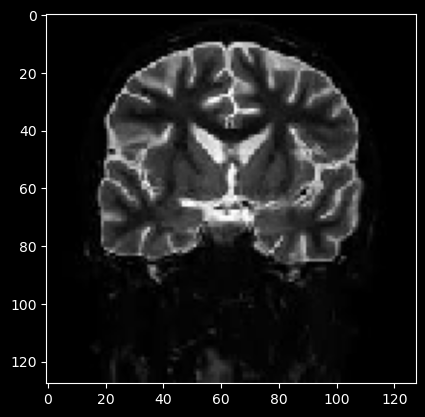

In [29]:
from tensorflow.keras.preprocessing import image
import numpy as np


# Load image
img = image.load_img(
    r"C:\Users\Shuhaib\OneDrive\Documents\archive (1)\no\19 no.jpg",
    target_size=(128, 128)
)
plt.imshow(img)
# Convert to array
img_array = image.img_to_array(img)

# Normalize (VERY IMPORTANT)
img_array = img_array / 255.0

# Expand dimensions instead of reshape (Correct way)
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)   # (1, 128, 128, 3)

# Predict
prediction = model.predict(img_array)

# Output result
if prediction[0][0] > 0.5:
    print("Prediction: Tumor (Yes)")
else:
    print("Prediction: No Tumor")

(1, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Prediction: Tumor (Yes)


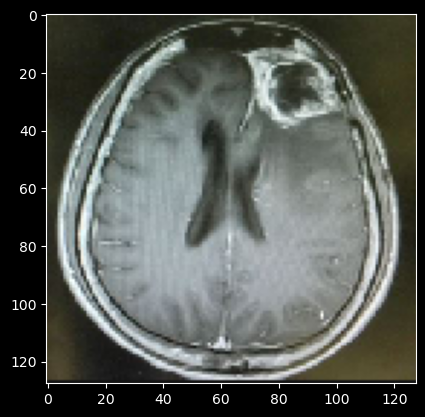

In [30]:

# Load image
img = image.load_img(
    r"C:\Users\Shuhaib\OneDrive\Documents\archive (1)\yes\Y47.JPG",
    target_size=(128, 128)
)
plt.imshow(img)
# Convert to array
img_array = image.img_to_array(img)

# Normalize (VERY IMPORTANT)
img_array = img_array / 255.0

# Expand dimensions instead of reshape (Correct way)
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)   # (1, 128, 128, 3)

# Predict
prediction = model.predict(img_array)

# Output result
if prediction[0][0] > 0.5:
    print("Prediction: Tumor (Yes)")
else:
    print("Prediction: No Tumor")